In [52]:
import pandas as pd
import numpy as  np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [53]:
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

In [54]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.datasets import load_diabetes

In [55]:
data = load_diabetes()

In [56]:
X = pd.DataFrame(
    data.data,
    columns=data.feature_names
)
y = pd.Series(
    data.target,
    name="target"
)
print("X : ", X.shape)
print("Y : ", y.shape)

X :  (442, 10)
Y :  (442,)


In [57]:
print(X.columns.tolist())

['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']


In [58]:
X.dtypes

age    float64
sex    float64
bmi    float64
bp     float64
s1     float64
s2     float64
s3     float64
s4     float64
s5     float64
s6     float64
dtype: object

In [59]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
dtypes: float64(10)
memory usage: 34.7 KB


In [60]:
X.isnull().sum()

age    0
sex    0
bmi    0
bp     0
s1     0
s2     0
s3     0
s4     0
s5     0
s6     0
dtype: int64

In [61]:
X.describe().T[
    ["min", "max", "mean", "std"]
]

,min,max,mean,std
age,-0.107226,0.110727,-2.511817e-19,0.047619
sex,-0.044642,0.050680,1.230790e-17,0.047619
bmi,-0.090275,0.170555,-2.245564e-16,0.047619
bp,-0.112399,0.132044,-4.797570e-17,0.047619
s1,-0.126781,0.153914,-1.381499e-17,0.047619
s2,-0.115613,0.198788,3.918434e-17,0.047619
s3,-0.102307,0.181179,-5.777179e-18,0.047619
s4,-0.076395,0.185234,-9.042540e-18,0.047619
s5,-0.126097,0.133597,9.268604e-17,0.047619
s6,-0.137767,0.135612,1.130318e-17,0.047619


In [62]:
X.duplicated().sum()

np.int64(0)

In [63]:
correlation = X.corrwith(y)
print(correlation.sort_values(ascending=False))

bmi    0.586450
s5     0.565883
bp     0.441482
s4     0.430453
s6     0.382483
s1     0.212022
age    0.187889
s2     0.174054
sex    0.043062
s3    -0.394789
dtype: float64


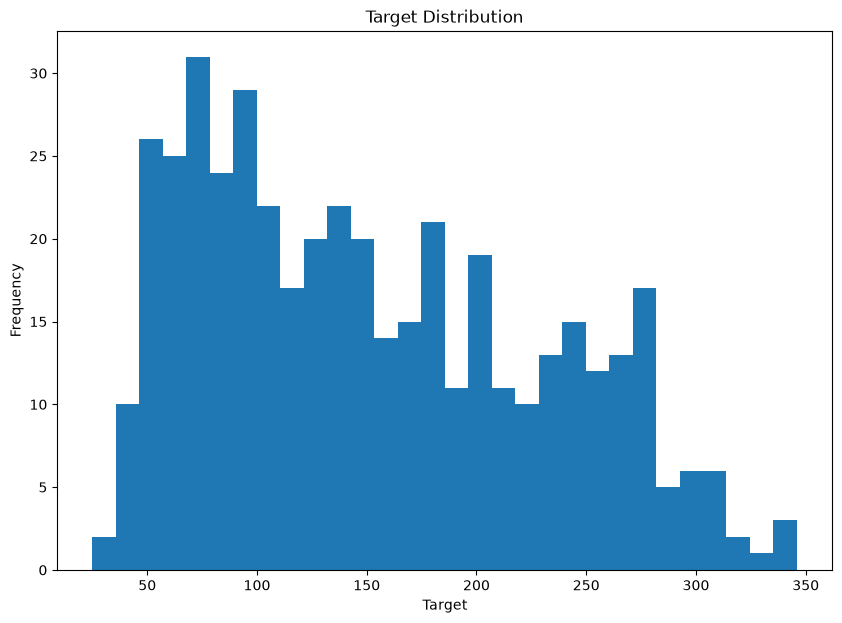

In [64]:
plt.figure(figsize=(10, 7))
plt.hist(y, bins=30)
plt.xlabel("Target")
plt.ylabel("Frequency")
plt.title("Target Distribution")
plt.show()

In [65]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [66]:
model = SVR(
    kernel="rbf",
    C=1.0,
    gamma="scale",
    epsilon=0.1
)

In [67]:
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2Score = r2_score(y_test, y_pred)
rmse = np.sqrt(mse)

print("Mean Squred Error : ", mse)
print("Mean Absolute Error : ", mae)
print("R2 Score : ", r2Score)
print("Adjusted R2 Score : ", rmse)

Mean Squred Error :  4332.738479345716
Mean Absolute Error :  56.02947330400618
R2 Score :  0.1822169909423953
Adjusted R2 Score :  65.82354046498651


In [68]:
result = pd.DataFrame({
    "Actual" : y_test.values,
    "Predicted" : y_pred
})
result.head(10)

,Actual,Predicted
0,219.0,142.352946
1,70.0,142.769973
2,202.0,141.795217
3,230.0,152.157467
4,111.0,136.806881
5,84.0,134.076347
6,242.0,155.359327
7,272.0,151.209073
8,94.0,127.762026
9,96.0,131.369191


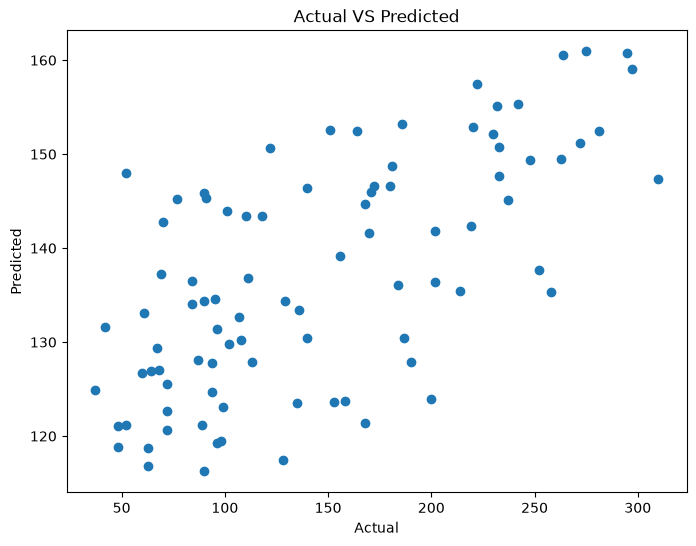

In [69]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual VS Predicted")
plt.show()

In [70]:
cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring="r2")
print(cv_scores)
print(cv_scores.mean())

[0.09154465 0.11447118 0.1007126  0.11200611 0.1412512 ]
0.11199714887795394


In [71]:
param_grid = {
    "C" : [
        0.1,
        1,
        10,
        100
    ],

    "kernel" : [
        "linear",
        "rbf",
        "poly"
    ],

    "gamma" : [
        "scale",
        "auto"
    ],

    "epsilon": [0.01, 0.1, 0.5, 1, 5, 10]
}

grid_search = GridSearchCV(
    estimator=SVR(),
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_scaled, y_train)

Fitting 5 folds for each of 144 candidates, totalling 720 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVR()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.1, 1, ...], 'epsilon': [0.01, 0.1, ...], 'gamma': ['scale', 'auto'], 'kernel': ['linear', 'rbf', ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_d

In [72]:
print("Best Params : ", grid_search.best_params_)
print("Best CV Score : ", grid_search.best_score_)
best_model = grid_search.best_estimator_
print("Best Model : ", best_model)

Best Params :  {'C': 1, 'epsilon': 0.5, 'gamma': 'scale', 'kernel': 'linear'}
Best CV Score :  0.4627317186170724
Best Model :  SVR(C=1, epsilon=0.5, kernel='linear')


In [73]:
y_pred_best = best_model.predict(X_test_scaled)

final_mse = mean_squared_error(y_test, y_pred_best)
final_mae = mean_absolute_error(y_test, y_pred_best)
final_rmse = np.sqrt(final_mse)
final_r2 = r2_score(y_test, y_pred_best)

print("Best K Value : ", grid_search.best_score_)
print("Best Mean Squred Error : ", final_mse)
print("Best Mean Absolute Error : ", final_mae)
print("Best R2 Score : ", final_r2)
print("Best Adjusted R2 Score : ", final_rmse)

Best K Value :  0.4627317186170724
Best Mean Squred Error :  2936.3428267529835
Best Mean Absolute Error :  43.324973311812776
Best R2 Score :  0.44577978017048814
Best Adjusted R2 Score :  54.18803213582297
